## 加载数据集

In [1]:
import json
import os
import requests

def download_and_load_file(file_path, url):
    if not os.path.exists(file_path):
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        text_data = response.text
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)

    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    return data

file_path = "instruction-data.json"
url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)

data = download_and_load_file(file_path, url)
print("Number of entries:", len(data))

Number of entries: 1100


In [2]:
def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""

    return instruction_text + input_text

model_input = format_input(data[50])
desired_response = f"\n\n### Response:\n{data[50]['output']}"
print(model_input + desired_response)


model_input = format_input(data[999])
desired_response = f"\n\n### Response:\n{data[999]['output']}"
print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is an antonym of 'complicated'?

### Response:
An antonym of 'complicated' is 'simple'.


In [3]:
train_portion = int(len(data) * 0.85)  # 85% 训练
test_portion = int(len(data) * 0.1)    # 10% 测试
val_portion = len(data) - train_portion - test_portion  # 剩余5%用于验证

train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion + test_portion:]

print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))


Training set length: 935
Validation set length: 55
Test set length: 110


In [4]:
import torch
def custom_collate_fn(batch,pad_token_id=50256,ignore_index=-100,
    allowed_max_length=None,device="cpu"):
    batch_max_length = max(len(item)+1 for item in batch)

    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])  
        targets = torch.tensor(padded[1:])  

        # New: Replace all but the first padding tokens in targets by ignore_index
        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index

        # New: Optionally truncate to maximum sequence length
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # Convert list of inputs and targets to tensors and transfer to target device
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)

    return inputs_tensor, targets_tensor

In [5]:
import torch

# ========== 1. 检测可用设备并指定GPU编号 ==========
if torch.cuda.is_available():
    # 指定使用第几张GPU（例如 gpu:0, gpu:1）
    gpu_id = 3  # ← 改成你想用的显卡编号
    
    # 检查指定的GPU是否存在
    if gpu_id >= torch.cuda.device_count():
        print(f"警告：GPU {gpu_id} 不存在，共有 {torch.cuda.device_count()} 张GPU")
        gpu_id = 0
    
    device = torch.device(f"cuda:{gpu_id}")
    
    # 设置当前进程可见的GPU（可选，防止程序占用其他卡）
    torch.cuda.set_device(gpu_id)
    
elif torch.backends.mps.is_available():
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")

print("Device:", device)

# ========== 2. 显示当前正在使用的GPU详细信息 ==========
if device.type == "cuda":
    # 当前使用的GPU编号和名称
    current_gpu = torch.cuda.current_device()
    gpu_name = torch.cuda.get_device_name(current_gpu)
    
    print(f"\n当前使用的GPU: cuda:{current_gpu}")
    print(f"GPU名称: {gpu_name}")
    print(f"显存总量: {torch.cuda.get_device_properties(current_gpu).total_memory / 1024**3:.2f} GB")
    
    # 显示所有可用的GPU
    print(f"\n系统中所有可用的GPU ({torch.cuda.device_count()} 张):")
    for i in range(torch.cuda.device_count()):
        name = torch.cuda.get_device_name(i)
        is_current = " ← 当前使用" if i == current_gpu else ""
        print(f"  cuda:{i} - {name}{is_current}")
    
    # 显存占用情况
    print(f"\n显存使用情况:")
    print(f"  已分配: {torch.cuda.memory_allocated(current_gpu) / 1024**2:.2f} MB")
    print(f"  保留缓存: {torch.cuda.memory_reserved(current_gpu) / 1024**2:.2f} MB")

Device: cuda:3

当前使用的GPU: cuda:3
GPU名称: NVIDIA GeForce RTX 3090
显存总量: 23.57 GB

系统中所有可用的GPU (4 张):
  cuda:0 - NVIDIA GeForce RTX 3090
  cuda:1 - NVIDIA GeForce RTX 3090
  cuda:2 - NVIDIA GeForce RTX 3090
  cuda:3 - NVIDIA GeForce RTX 3090 ← 当前使用

显存使用情况:
  已分配: 0.00 MB
  保留缓存: 0.00 MB


In [6]:
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import torch
from functools import partial

customized_collate_fn = partial(
    custom_collate_fn,
    device=device,
    allowed_max_length=1024
)

class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data

        self.encoded_texts = []
        for entry in data:
            # 文本格式化
            instruction_plus_input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry['output']}"
            full_text = instruction_plus_input + response_text
            # 词元化
            self.encoded_texts.append(
                tokenizer.encode(full_text)
            )

    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.data)

num_workers = 0
batch_size = 8

torch.manual_seed(123)
# 创建数据集
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
train_dataset = InstructionDataset(train_data, tokenizer)
# 创建数据加载器
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)

val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

print("Train loader:")
for inputs, targets in train_loader:
    print(inputs.shape, targets.shape)

Train loader:
torch.Size([8, 61]) torch.Size([8, 61])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 75]) torch.Size([8, 75])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 79]) torch.Size([8, 79])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 83]) torch.Size([8, 83])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 68]) torch.

## 初始化模型

我们复用第7章中的代码来加载和准备预训练的GPT模型。首先，下载模型权重（执行本目录下downloadModel.sh文件即可），并将其加载到GPTModel类中

In [7]:
import sys
import os
# 获取当前文件的目录
root_dir = os.path.dirname(os.path.abspath(".."))  
# 把根目录加入 sys.path
sys.path.append(root_dir)

from ch04.GPTModel import GPTModel
from ch05.modelUtils import load_hf_weights_into_custom_gpt

BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}
CHOOSE_MODEL = "gpt2-medium (355M)"
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])
model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")

model = GPTModel(BASE_CONFIG)
weights_path = f"gpt2/355M/pytorch_model.bin"
hf_weights = torch.load(weights_path, map_location=device)

# 先检查实际 key
print("前 20 个 key:")
for i, key in enumerate(hf_weights.keys()):
    print(key)
    if i >= 19:
        break

# 检查关键权重 shape
def find_key(weights, suffix):
    for k in weights.keys():
        if k == suffix or k.endswith("." + suffix):
            return k
    raise KeyError(f"找不到以 {suffix} 结尾的 key")
for suffix in [
    "h.0.attn.c_attn.weight",
    "h.0.attn.c_proj.weight",
    "h.0.mlp.c_fc.weight",
    "h.0.mlp.c_proj.weight",
]:
    real_key = find_key(hf_weights, suffix)
    print(real_key, hf_weights[real_key].shape)


前 20 个 key:
wte.weight
wpe.weight
h.0.ln_1.weight
h.0.ln_1.bias
h.0.attn.bias
h.0.attn.c_attn.weight
h.0.attn.c_attn.bias
h.0.attn.c_proj.weight
h.0.attn.c_proj.bias
h.0.ln_2.weight
h.0.ln_2.bias
h.0.mlp.c_fc.weight
h.0.mlp.c_fc.bias
h.0.mlp.c_proj.weight
h.0.mlp.c_proj.bias
h.1.ln_1.weight
h.1.ln_1.bias
h.1.attn.bias
h.1.attn.c_attn.weight
h.1.attn.c_attn.bias
h.0.attn.c_attn.weight torch.Size([1024, 3072])
h.0.attn.c_proj.weight torch.Size([1024, 1024])
h.0.mlp.c_fc.weight torch.Size([1024, 4096])
h.0.mlp.c_proj.weight torch.Size([4096, 1024])


In [8]:
load_hf_weights_into_custom_gpt(model, hf_weights, BASE_CONFIG)
model.eval()

HF 权重加载完成: 24 层, emb_dim=1024


GPTModel(
  (tok_emb): Embedding(50257, 1024)
  (pos_emb): Embedding(1024, 1024)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MutilHeadAttention(
        (W_query): Linear(in_features=1024, out_features=1024, bias=True)
        (W_key): Linear(in_features=1024, out_features=1024, bias=True)
        (W_value): Linear(in_features=1024, out_features=1024, bias=True)
        (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=1024, out_features=4096, bias=True)
          (1): GELU()
          (2): Linear(in_features=4096, out_features=1024, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MutilHeadAttention(
        (W_query): Linear(i

## LoRA微调
全量微调大模型（如 GPT-3 175B）需要更新所有参数，显存和计算成本极高。

LoRA 的解决方式：
冻结预训练权重 W0，只训练两个低秩矩阵 A  和 B  的乘积来近似权重更新 ΔW 。
h=W0x+ΔWx=W0x+BAx 
其中：
W0∈Rd×k — 冻结的预训练权重
A∈Rd×r — 可训练，随机初始化
B∈Rr×k — 可训练，零初始化
r≪min(d,k)  — 低秩，通常 r=4,8,16,64 

In [9]:
import math

class LoRALayer(torch.nn.Module):
    def __init__(self, in_dim, out_dim, rank, alpha):
        super().__init__()
        # 随机初始化矩阵A， 提供多样性，让模型能学习不同的低秩方向。
        self.A = torch.nn.Parameter(torch.empty(in_dim, rank))
        torch.nn.init.kaiming_uniform_(self.A, a=math.sqrt(5))  
        # 零初始化矩阵B
        """
        训练开始时，BA=0×A=0 ，所以 ΔW=BA=0 。
        这意味着：LoRA 初始状态对模型输出没有任何影响，模型先从预训练权重 W0开始，然后逐渐学习调整。
        如果 B 也随机初始化，训练初期会引入巨大噪声，破坏预训练知识。
        """
        self.B = torch.nn.Parameter(torch.zeros(rank, out_dim))
        self.alpha = alpha
        self.rank = rank

    def forward(self, x):
        x = (self.alpha / self.rank) * (x @ self.A @ self.B)
        return x

rank控制着矩阵A和B的内部维度。本质上，该设置决定了LoRA引入的额外参数量，从而在模型的适应性和效率之间建立平衡。

另一个重要的设置是alpha，它作为低秩自适应输出的缩放因子，主要决定了适应层的输出对原始层输出的影响程度。这可以被视为调节低秩适应对层输出影响的一种方式。到目前为止，我们实现的LoRALayer类使我们能够对层的输入进行转换。

在LoRA中，典型的目标是替换现有的线性层，从而允许权重更新直接应用于已有的预训练权重

为了整合原始线性层的权重，现在创建一个LinearWithLoRA层。该层利用之前实现的LoRALayer，旨在替换神经网络中现有的线性层，比如GPTModel中的自注意力模块或前馈模块

In [10]:
class LinearWithLoRA(torch.nn.Module):
    def __init__(self, linear, rank, alpha):
        super().__init__()
        self.linear = linear
        self.lora = LoRALayer(
            linear.in_features, linear.out_features, rank, alpha
        )

    def forward(self, x):
        return self.linear(x) + self.lora(x)

上述代码将标准线性层与LoRALayer结合在了一起。forward方法通过将原始线性层和LoRA层的结果相加来计算输出。

为了将LoRA应用到之前定义的GPTModel中，我们引入了replace_linear_ with_lora函数。该函数会将模型中所有现有的Linear层替换为新创建的LinearWithLoRA层。


In [11]:
def replace_linear_with_lora(model, rank, alpha):
    for name, module in model.named_children():
        if isinstance(module, torch.nn.Linear):
            # Replace the Linear layer with LinearWithLoRA
            setattr(model, name, LinearWithLoRA(module, rank, alpha))
        else:
            # Recursively apply the same function to child modules
            replace_linear_with_lora(module, rank, alpha)

现在我们已经实现了所有必要的代码，将GPTModel中的Linear层替换为新开发的LinearWithLoRA层，以便进行参数高效微调。接下来，我们将把LinearWithLoRA应用到GPTModel的多头注意力模块、前馈模块以及输出层中的所有Linear层

![gptWithLoRA](imgs/gptWithLoRA.png)

在使用LinearWithLoRA层升级之前，首先冻结原始模型的参数

初始状态：所有参数 requires_grad=True

                ↓

遍历每个参数：param.requires_grad = False

                ↓

冻结后：所有参数 requires_grad=False

                ↓

反向传播时：

    - 只计算 requires_grad=True 的参数的梯度

    - requires_grad=False 的参数被跳过

                ↓

优化器 step() 时：

    - 只更新有梯度的参数

    - 冻结参数保持原值不变
    

In [12]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters before: {total_params:,}")
# 冻结操作，反向传播不计算梯度，参数冻结不动
for param in model.parameters():
    param.requires_grad = False

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters after: {total_params:,}")

Total trainable parameters before: 354,823,168
Total trainable parameters after: 0


可以看到在3.54亿个模型参数中，没有一个是可训练的

接下来，使用replace_linear_with_lora来替换Linear层

由于 LoRA 层是新加的，它的 A 和 B 默认 requires_grad=True，即使原始 Linear 被冻结，新加的 lora 子模块的参数仍然是可训练的：

In [13]:
replace_linear_with_lora(model, rank=16, alpha=16)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable LoRA parameters: {total_params:,}")

Total trainable LoRA parameters: 7,898,384


在添加LoRA层后，可训练的模型参数量如上所示.如你所见，使用LoRA时，我们将可训练参数的数量减少到了原来的1/44。将rank和alpha设置为16是一个不错的默认选择，但增加rank参数也很常见，这反过来会增加可训练参数的数量。通常选择将alpha设置为rank的一半、两倍或等于rank的值。

接下来，通过打印模型架构来验证各层是否已按预期修改

In [14]:
model.to(device)

print(model)

GPTModel(
  (tok_emb): Embedding(50257, 1024)
  (pos_emb): Embedding(1024, 1024)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MutilHeadAttention(
        (W_query): LinearWithLoRA(
          (linear): Linear(in_features=1024, out_features=1024, bias=True)
          (lora): LoRALayer()
        )
        (W_key): LinearWithLoRA(
          (linear): Linear(in_features=1024, out_features=1024, bias=True)
          (lora): LoRALayer()
        )
        (W_value): LinearWithLoRA(
          (linear): Linear(in_features=1024, out_features=1024, bias=True)
          (lora): LoRALayer()
        )
        (out_proj): LinearWithLoRA(
          (linear): Linear(in_features=1024, out_features=1024, bias=True)
          (lora): LoRALayer()
        )
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): LinearWithLoRA(
            (linear): Linear(in_features=1024

该模型现在包含新的LinearWithLoRA层，这些层由设置为不可训练的原始Linear层和新的LoRA层组成，我们将对后者进行微调。

现在，让我们先花一些时间，通过将模型输出与预期的回复进行比较，来评估预训练的大语言模型在验证任务上的表现。这将为我们提供一个模型的基准性能指标，该指标反映了模型在未经微调的情况下在指令遵循任务中的表现情况，并能帮助我们更好地理解微调后的效果。下面我们将使用验证集中第一个样本进行评估

In [20]:
torch.manual_seed(123)

input_text = format_input(val_data[0])
# input_text = format_input(val_data[0]) + "\n\n### Response:\n"
print(input_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


In [21]:
device = next(model.parameters()).device  # 获取模型所在设备
print(device)

cuda:3


In [19]:
from ch05.modelUtils import generate,text_to_token_ids,token_ids_to_text
token_ids = generate(
    model=model,
    idx=text_to_token_ids(input_text, tokenizer).to(device=device),
    max_new_tokens=35,
    context_size=BASE_CONFIG["context_length"],
    eos_id=50256,
)
generated_text = token_ids_to_text(token_ids, tokenizer)
print(generated_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'

### Response:

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the


In [22]:
response_text = generated_text[len(input_text):].strip()
print(response_text)

### Response:

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the


上述输出显示，预训练模型还不能正确遵循给定的指令。尽管它“有模有样”地生成了回复部分### Response，但只是简单地重复了输入的句子和部分指令，未能按照要求将主动句转换为被动句。因此，我们需要实施微调过程，以提升模型理解和正确回复此类请求的能力

在真正开始微调之前，我们先看一下微调前的模型损失

In [23]:
from ch05.modelUtils import calc_loss_loader,train_model_simple
model.to(device)

torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 3.8259100914001465
Validation loss: 3.7619341373443604


上述损失与第7章中的值相同。出现这一结果是因为LoRA矩阵B被初始化为零，因此矩阵AB的乘积产生了零矩阵。这确保了乘法不会改变原始权重，因为加零不会对它们产生影响。

接下来我们开始进行微调

In [24]:
import time
start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.00005, weight_decay=0.1)
num_epochs = 2
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context=format_input(val_data[0]), tokenizer=tokenizer
)
end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 3.624, Val loss 3.530
Ep 1 (Step 000005): Train loss 2.837, Val loss 2.802
Ep 1 (Step 000010): Train loss 2.361, Val loss 2.391
Ep 1 (Step 000015): Train loss 2.058, Val loss 2.075
Ep 1 (Step 000020): Train loss 1.743, Val loss 1.794
Ep 1 (Step 000025): Train loss 1.503, Val loss 1.561
Ep 1 (Step 000030): Train loss 1.378, Val loss 1.362
Ep 1 (Step 000035): Train loss 1.144, Val loss 1.193
Ep 1 (Step 000040): Train loss 1.052, Val loss 1.097
Ep 1 (Step 000045): Train loss 0.952, Val loss 1.039
Ep 1 (Step 000050): Train loss 1.007, Val loss 1.001
Ep 1 (Step 000055): Train loss 1.036, Val loss 0.975
Ep 1 (Step 000060): Train loss 0.998, Val loss 0.956
Ep 1 (Step 000065): Train loss 0.885, Val loss 0.938
Ep 1 (Step 000070): Train loss 0.817, Val loss 0.926
Ep 1 (Step 000075): Train loss 0.821, Val loss 0.917
Ep 1 (Step 000080): Train loss 0.919, Val loss 0.906
Ep 1 (Step 000085): Train loss 0.786, Val loss 0.896
Ep 1 (Step 000090): Train loss 0.830, Val loss

如你所见，该模型经过了充分的训练，loss已经足够低。但是在同一设备下，其训练的时间仅仅只有0.82分钟，相比于全量微调花费的2.08分钟时巨大的提升。下面让我们可视化损失曲线，以更好地观察训练是否收敛。

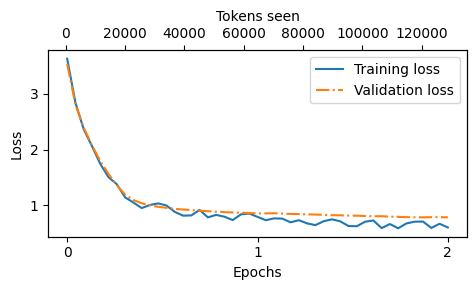

In [25]:
from ch05.modelUtils import plot_losses

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

接下来我们继续使用第7章的方式对模型进行评估

In [27]:
import requests  

def query_model(
    prompt,                          # 用户输入的提示文本
    model="llama3",                  # 默认使用 llama3 模型
    url="http://localhost:11434/api/chat"  # Ollama 的本地 API 地址
):
    # 创建一个请求体
    data = {
        "model": model,
        "messages": [
            {"role": "user", "content": prompt}
        ],
        "options": {
            "seed": 123,           # 随机种子，固定后输出可复现
            "temperature": 0,      # 温度=0，贪婪解码，输出最确定的答案
            "num_ctx": 2048        # 上下文窗口长度（token 数）
        }
    }

    
    # 发送post请求
    # Ollama 的 /api/chat 返回的是 NDJSON（Newline Delimited JSON），即每生成一个 token 就发一行 JSON
    # 如果不流式（stream=True），就要等模型全部生成完才能拿到结果，对于长文本会很慢。
    with requests.post(url, json=data, stream=True, timeout=30) as r:
        r.raise_for_status()          # HTTP 状态码非 2xx 时抛出异常
        response_data = ""            # 累积完整回复

        for line in r.iter_lines(decode_unicode=True):  # 逐行读取流
            if not line:
                continue              # 跳过空行
            
            response_json = json.loads(line)  # 每行是一个 JSON 对象
            
            if "message" in response_json:
                response_data += response_json["message"]["content"]  # 拼接 token
    return response_data

model = "llama3"
result = query_model("What do Llamas eat?", model)
print(result)

Llamas are herbivores, which means they primarily feed on plant-based foods. Their diet typically consists of:

1. Grasses: Llamas love to graze on various types of grasses, including tall grasses, short grasses, and even weeds.
2. Hay: High-quality hay, such as alfalfa or timothy hay, is a staple in a llama's diet. They enjoy the sweet taste and texture of fresh hay.
3. Grains: Llamas may receive grains like oats, barley, or corn as part of their daily ration. However, it's essential to provide these grains in moderation, as they can be high in calories.
4. Fruits and vegetables: Llamas enjoy a variety of fruits and veggies, such as apples, carrots, sweet potatoes, and leafy greens like kale or spinach.
5. Minerals: Llamas require access to mineral supplements, which help maintain their overall health and digestive system.

In the wild, llamas might also eat:

1. Leaves: They'll munch on leaves from trees and shrubs, like willow, alder, or birch.
2. Bark: In some cases, llamas may eat

In [30]:
import json
from tqdm import tqdm

file_path = "instruction-data-with-response.json"

with open(file_path, "r") as file:
    test_data = json.load(file)

# 接下来这段代码加载了我们之前创建的指令和回复数据文件，
# 并重新定义了函数format_input​。
def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""

    return instruction_text + input_text

In [32]:
def generate_model_scores(json_data, json_key, model="llama3"):
    scores = []
    for entry in tqdm(json_data, desc="Scoring entries"):
        prompt = (
            f"Given the input `{format_input(entry)}` "
            f"and correct output `{entry['output']}`, "
            f"score the model response `{entry[json_key]}`"
            f" on a scale from 0 to 100, where 100 is the best score. "
            f"Respond with the integer number only."
        )
        score = query_model(prompt, model)
        try:
            scores.append(int(score))
        except ValueError:
            print(f"Could not convert score: {score}")
            continue

    return scores


scores = generate_model_scores(test_data, "model_response")
print(f"Number of scores: {len(scores)} of {len(test_data)}")
print(f"Average score: {sum(scores)/len(scores):.2f}\n")

Scoring entries:   9%|▉         | 10/110 [00:03<00:50,  1.99it/s]

Could not convert score: I'd be happy to help!

For the first instruction:

Score: 80

My response was: Prime numbers: 11, 19
Composite numbers: 14

The model's response was slightly off from the correct output, but it still got the main points right.

For the second instruction:

Score: 0

My response was: Prime: 11
Composite: 14

Unfortunately, my response didn't match the input at all.


Scoring entries:  71%|███████   | 78/110 [00:24<00:12,  2.54it/s]

Could not convert score: Here's my attempt:

**Model Response:** Swim: Verb
Beautiful: Adjective
Quickly: Adverb

**Score:** 100


Scoring entries: 100%|██████████| 110/110 [00:34<00:00,  3.20it/s]

Number of scores: 108 of 110
Average score: 46.73



评估结果表明，微调后的模型平均分数接近50，与之前第7章使用全量微调的分数一样，结合之前的loss和训练时间，这说明LoRA确实能在保证精度的前提下减少训练时间